# Add a test set

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# note the random split
import torch
import torch.nn as nn 
import torch.nn.functional as F 
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# GPT-2's tokenizer
from transformers import GPT2Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

/Users/shre/courses/llm_deep_dive/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# data hyperparameters
seq_len = 8 # aka context length
stride = 2

# model hyperparameters
embed_dim = 128

# training hyperparameters
batch_size = 64

## create train and test sets

In [5]:
# download and tokenize the text
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)

Token indices sequence length is longer than the specified maximum sequence length for this model (48533 > 1024). Running this sequence through the model will result in indexing errors


48533

In [6]:
# create a class for a dataset (note: batching is done by the DataLoader, not in the dataset)
class TokenDataset(Dataset):
    def __init__(self, tokens, seq_len=8, stride=4) -> None:
        # initialize
        self.inputs = []
        self.targets = []

        # overlapping sequences of seq_len
        for i in range(0, len(tokens)-seq_len, stride):
            # get c tokens and append to lists
            self.inputs.append(tokens[i: i+seq_len])
            self.targets.append(tokens[i+1 : i+1+seq_len])
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]

In [7]:
# create an instance
token_dataset = TokenDataset(tmTokens, seq_len, stride)

# split into train and test
train_ratio = .9
train_size = int(train_ratio * len(token_dataset))
test_size = len(token_dataset) - train_size

# create train/test subset
train_dataset, test_dataset = random_split(token_dataset, [train_size, test_size])

# create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Train set has {train_size:5} sequences.')
print(f'Test set has  {test_size:5} sequences.')

Train set has 21836 sequences.
Test set has   2427 sequences.


## create the model

In [8]:
class Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        # embedding matrix
        self.embedding = nn.Embedding(tokenizer.vocab_size, embed_dim)

        # embedding to output layer
        self.gelu = nn.GELU()
        self.finalLinear = nn.Linear(embed_dim, tokenizer.vocab_size)
    
    def forward(self, tokx):
        # forward pass
        x = self.embedding(tokx) # [batch, token, embeddings]
        x = self.gelu(x)
        x = self.finalLinear(x) # [embeddings, vocab]

        # return lof-softmax
        return F.log_softmax(x,dim=-1)
    
    def generate(self, tokx, n_new_tokens = 30):
        for _ in range(n_new_tokens):
            x = self(tokx)
            x = x[:, -1, :]
            probs = torch.exp(x) # undo the log but keep the softmax
            nextToken = torch.multinomial(probs, num_samples=1)
            tokx = torch.cat( (tokx,nextToken),dim=1)
        
        return tokx

In [9]:
# create an instance and test
model = Model()
X,y = token_dataset[1]
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([8])
torch.Size([8])
torch.Size([8, 50257])


In [10]:
print(X)
print(y)

tensor([ 3963,  3336, 21965, 23680,   402,  3843,  1677, 13246])
tensor([ 3336, 21965, 23680,   402,  3843,  1677, 13246,    38])


In [11]:
# confirm the probability distribution

print(torch.sum(torch.exp(out))) # does sum(exp) == exp(sum)?
print(torch.min(torch.exp(out)))
print(torch.max(torch.exp(out)))

tensor(8.0000, grad_fn=<SumBackward0>)
tensor(3.2410e-06, grad_fn=<MinBackward1>)
tensor(0.0001, grad_fn=<MaxBackward1>)


## Training

In [12]:
# push the model to the GPU
model = model.to(device)

# create the loss and optimizer functions
loss_function = nn.NLLLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=.001, weight_decay=.01)

In [13]:
num_epochs = 10

# initialize losses
train_loss = []
test_loss = []

for epoch in range(num_epochs):
    epoch_loss = 0

    for X, y in train_dataloader:
        X,y = X.to(device), y.to(device)
        model.zero_grad()
        log_probs = model(X)
        log_probs_flat = log_probs.view(-1,log_probs.shape[-1])
        y_flat = y.view(-1)
        loss = loss_function(log_probs_flat, y_flat)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # evaluate the model with the test set
    with torch.no_grad():
        testloss = 0 # reset the test loss
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            out_flat = out.reshape(-1, out.shape[-1])
            thisloss = loss_function(out_flat, y.view(-1))
            testloss += thisloss.item()
    
    # scale the train loss by the number of tokens in this dataloader
    train_loss.append(epoch_loss / len(train_dataloader))
    test_loss.append(testloss / len(test_dataloader))

    # update our progress
    print(f'Epoch {epoch+1:2}, train loss: {epoch_loss / len(train_dataloader):.4f}, test loss: {testloss/len(test_dataloader):.4f}')

Epoch  1, train loss: 6.3026, test loss: 4.9381
Epoch  2, train loss: 4.4834, test loss: 4.3712
Epoch  3, train loss: 4.0066, test loss: 4.0368
Epoch  4, train loss: 3.7094, test loss: 3.8112
Epoch  5, train loss: 3.5128, test loss: 3.6465
Epoch  6, train loss: 3.3713, test loss: 3.5232
Epoch  7, train loss: 3.2649, test loss: 3.4257
Epoch  8, train loss: 3.1800, test loss: 3.3488
Epoch  9, train loss: 3.1120, test loss: 3.2850
Epoch 10, train loss: 3.0565, test loss: 3.2331


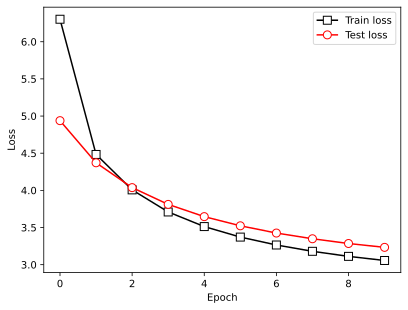

In [14]:
# plot the losses
plt.plot(train_loss, 'ks-', markerfacecolor='w', markersize=8, label='Train loss')
plt.plot(test_loss, 'ro-', markerfacecolor='w', markersize=8, label='Test loss')

plt.legend()
plt.gca().set(xlabel='Epoch', ylabel='Loss')
plt.show()

In [15]:
# generate new text
startToks = torch.tensor(tokenizer.encode('I thought the Eloi would be smarter than')).unsqueeze(0)

# text generation
Y = model.generate(startToks.to(device))
print(tokenizer.decode(Y[0].tolist()).replace('\r','\n'))

I thought the Eloi would be smarter than we move we should havethud, and



”

several,

attention up and vague sense of no
